In [167]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve,precision_score, recall_score, f1_score,ConfusionMatrixDisplay,precision_recall_curve,log_loss
from sklearn.pipeline import Pipeline
from scipy.stats import shapiro
from sklearn.tree import DecisionTreeClassifier

In [159]:
##Data to be used
data = pd.read_csv('forModel.csv')
data.drop(['Checkup','Unnamed: 0.1','Unnamed: 0'], axis = 1, inplace =True)

##Cloned Data 
clonedData = pd.read_csv('forModel.csv')
clonedData['Heart_Disease'] = clonedData['Heart_Disease'].map({'Yes':1,'No':0})
data.head(5)

,General_Health,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,SexBinary
0,Very Good,Yes,No,No,No,No,No,Yes,Female,55-59,170.0,68.04,23.49,No,0.0,90.0,4.0,1.0,0
1,Excellent,No,No,No,No,No,No,No,Female,80+,168.0,77.11,27.44,Yes,30.0,2.0,30.0,0.0,0
2,Good,Yes,No,Yes,No,No,No,Yes,Female,80+,175.0,72.57,23.63,No,0.0,60.0,20.0,1.0,0
3,Very Good,Yes,No,No,No,No,No,No,Male,55-59,180.0,99.79,30.68,No,20.0,30.0,16.0,4.0,1
4,Good,Yes,No,No,No,No,No,Yes,Male,30-34,188.0,70.31,19.90,Yes,24.0,8.0,24.0,20.0,1


In [160]:
data['General_Health'] = data['General_Health'].apply(lambda x: 'Poor' if x == 'Poor' else 'Good')
data['General_Health'] = data['General_Health'].map({"Poor":1, "Good":0})
data['Sex'] = data['Sex'].map({'Male':1, 'Female':0})
data['Diabetes'] = data['Diabetes'].apply(lambda x:'No' if x == 'No' else 'Yes')
## Since most of the Binary have Yes and No we will convert all of them at once 
cols = ['Exercise','Heart_Disease','Skin_Cancer','Other_Cancer','Depression','Arthritis','Smoking_History','Diabetes']
for each in cols:
    data[each] = data[each].map({'Yes':1,'No':0}) ##This converts the whole data into the binary 

dummied_data = pd.get_dummies(data, columns=['Age_Category'], dtype = 'int')

In [161]:
dummied_data.head(5)

,General_Health,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Height_(cm),...,Age_Category_35-39,Age_Category_40-44,Age_Category_45-49,Age_Category_50-54,Age_Category_55-59,Age_Category_60-64,Age_Category_65-69,Age_Category_70-74,Age_Category_75-79,Age_Category_80+
0,0,1,0,0,0,0,0,1,0,170.0,...,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,168.0,...,0,0,0,0,0,0,0,0,0,1
2,0,1,0,1,0,0,0,1,0,175.0,...,0,0,0,0,0,0,0,0,0,1
3,0,1,0,0,0,0,0,0,1,180.0,...,0,0,0,0,1,0,0,0,0,0
4,0,1,0,0,0,0,0,1,1,188.0,...,0,0,0,0,0,0,0,0,0,0


### Lets see how does the model performs with and without hyperparameter tuning and also figure out what are the effects of the different hyperparameter tuning such as Grid Search Cv, Randomized Cv and Bayesian Optimization 


In [162]:
X = dummied_data.drop(columns = 'Heart_Disease', axis = 1)
y = dummied_data['Heart_Disease']
X_train, X_test, y_train , y_test = train_test_split(X,y , test_size= 0.2, random_state= 52)




### Lets train the logistic model with Randomized Search Cv adding hyperparameters such as Regularization Parameter (C) and  penalty for the model in case it does overfitting and underfitting

In [163]:

pipeline_steps = [('scalar', StandardScaler()), ('model', LogisticRegression(solver='liblinear', max_iter=5000))]
pipeline = Pipeline(steps= pipeline_steps)
parameters = {'model__C':[0.001,0.01,0.1,1,10,100,1000], 'model__penalty':['l1','l2']}
hyper_tuned = GridSearchCV(pipeline, param_grid=parameters, cv = 5, n_jobs = -1)
hyper_tuned.fit(X_train, y_train)
best_logit_model = hyper_tuned.best_estimator_

## here now I will use the following metrics to calculate the precision, recall, fpr, f1-score, accuracy, roc-auc score of the model that we are using 
training_pred = best_logit_model.predict(X_train)
testing_pred = best_logit_model.predict(X_test)
testing_proba = best_logit_model.predict_proba(X_test)[:,1]

### Computing the evaluating metrices 
## 1. Training Accuracy vs Testing Accuracy 
testing_accuracy = accuracy_score(y_test, testing_pred)
training_accuracy = accuracy_score(y_train, training_pred)
print(f"The training accuracy of the model is {training_accuracy:.2f}")
print(f"The testing accuacy of the model is {testing_accuracy:.2f}")

## Precision, Recall(TPR), F1-Score, FPR
## Here I will be using the manual way of caluclating precision,recall and f1-score with the help of confusion matrix
evaluating_matrix = confusion_matrix(y_test, testing_pred)
true_negatives = evaluating_matrix[0][0]
false_positives = evaluating_matrix[0][1]
false_negatives = evaluating_matrix[1][0]
true_positives = evaluating_matrix[1][1]


#Calculating 
# Precison:
print("EVALUATION OF THE MODEL :")
precision = true_positives / (true_positives + false_positives)
print(f"The precision of the Logistic Model after hypertuning is {precision:.2f} meaning out of all the prediced positive cases {precision:.2f} were positive")
# Recall: 
recall = true_positives / (true_positives + false_negatives)
print(f"The recall of the Logistic Model after hypertuning is {recall:.2f} meaning out of all the positive cases, model predicted{recall:.2f} of them ")
# F1-Score:
f1_value = 2* (precision*recall)/ (precision+recall)
print(f"The f1-score to balance out the precision and recall for the given model is {f1_value}")
# False-Positive Rate:
fpr = false_positives/(false_positives+ true_negatives)
print(f"The False Positive Rate of the model is {fpr:.2f} meaning out of all the negative cases the model predicted {fpr:.2f} incorrectly")
#Roc-Auc curve: 
tpr, fpr, threshold = roc_curve(y_test, testing_proba)
roc_score = roc_auc_score(y_test, testing_proba)
print(f"The roc-auc score of the model is {roc_score} meaning the model correctly distinguish positive from negative by {roc_score *100:.2f}%.")





The training accuracy of the model is 0.74
The testing accuacy of the model is 0.74
EVALUATION OF THE MODEL :
The precision of the Logistic Model after hypertuning is 0.73 meaning out of all the prediced positive cases 0.73 were positive
The recall of the Logistic Model after hypertuning is 0.78 meaning out of all the positive cases, model predicted0.78 of them 
The f1-score to balance out the precision and recall for the given model is 0.7506822730305053
The False Positive Rate of the model is 0.29 meaning out of all the negative cases the model predicted 0.29 incorrectly
The roc-auc score of the model is 0.8177873619415411 meaning the model correctly distinguish positive from negative by 81.78%.


### Linear SVM 

In [164]:
### Lets do same for the Linear SVm 
pipeline_steps = [('scalar', StandardScaler()), ('svm', LinearSVC())]
svm = Pipeline(steps=pipeline_steps)
paramters = {'svm__C': [0.001,0.01,0.1,1,10,100]} ## here we are not adding penalty becuase the Linear SVM is itself a Ridge Regression model
hyper_tuned = GridSearchCV(svm, param_grid=paramters, cv = 5,n_jobs = -1)
hyper_tuned.fit(X_train, y_train)
best_linear_model = hyper_tuned.best_estimator_

## Lets evaluate the metrics that we might need later for the evaluation of the model 

training_pred = best_linear_model.predict(X_train)
testing_pred = best_linear_model.predict(X_test)
testing_boundaries = best_linear_model.decision_function(X_test)[:]

## Lets compute the accuracy_score, precision, recall, fpr, f1-score, roc-auc score and many more 
## I will be using the inbuilt scikitlearn features to calculate the metrics such as precision, recall, f1-score and accuracy-score

testing_accuracy = accuracy_score(y_test, testing_pred)
training_accuracy = accuracy_score(y_train, training_pred)

print(f"The training score of the model is {training_accuracy * 100:.2f} and testing score of the model is {testing_accuracy * 100:.2f} ")


precision = precision_score(y_test, testing_pred)
recall = recall_score(y_test, testing_pred)
f1_value = f1_score(y_test, testing_pred)
fpr, tpr, threshold = roc_curve(y_test, testing_boundaries)
roc_score = roc_auc_score(y_test, testing_boundaries)
print(f"EVALUATION OF THE MODEL:")
print(f"Out of the total predicted values the model gets {precision * 100:.2f}% times correct")
print(f"Whereas in reality, out of the total actual positive cases the model got {recall * 100:.2f}% times correct")
print(f"The harmonic mean between precision and recall is {f1_value *100:.2f}%")
print(f"The model successfully distinguished positive cases from negative cases {roc_score* 100:.2f}%")



The training score of the model is 74.45 and testing score of the model is 74.24 
EVALUATION OF THE MODEL:
Out of the total predicted values the model gets 72.26% times correct
Whereas in reality, out of the total actual positive cases the model got 78.33% times correct
The harmonic mean between precision and recall is 75.18%
The model successfully distinguished positive cases from negative cases 81.72%


### Since we are evaluating the chance of getting heart disease, The false Negative Cases are more vulnerable compared to the False Positive Cases. We cannot miss the cases where a patient has a heart problem. It is more important to consider the fact that False negative cases will be more expensive in this case ! so I am decreasing the threshold which makes sure that the model has the chance decreasing the case of true negatives and improve the recall !

In [165]:
pipeline_steps = [('scalar', StandardScaler()), ('model', LogisticRegression(solver='liblinear', max_iter=5000))]
pipeline = Pipeline(steps= pipeline_steps)
parameters = {'model__C':[0.001,0.01,0.1,1,10,100,1000], 'model__penalty':['l1','l2']}
hyper_tuned = GridSearchCV(pipeline, param_grid=parameters, cv = 5, n_jobs = -1)
hyper_tuned.fit(X_train, y_train)
best_logit_model = hyper_tuned.best_estimator_

## here now I will use the following metrics to calculate the precision, recall, fpr, f1-score, accuracy, roc-auc score of the model that we are using 
training_pred = best_logit_model.predict(X_train)
testing_pred = best_logit_model.predict(X_test)
testing_proba = best_logit_model.predict_proba(X_test)[:,1]
training_proba = best_logit_model.predict_proba(X_train)[:,1]

### These are the three different measures that we will be using in order to figure out our precision, recall, f1-socre, accuracy and many more 
## Evaluating with the samethreshold 
testing_accuracy = accuracy_score(y_test, testing_pred)
training_accuracy = accuracy_score(y_train, training_pred)
precison = precision_score(y_test, testing_pred)
recall = recall_score(y_test, testing_pred)
tpr, fpr, threshold = roc_curve(y_test, testing_proba)
roc_score = roc_auc_score(y_test, testing_proba)
evaluation_matrix = confusion_matrix(y_test, testing_pred)
display = ConfusionMatrixDisplay(confusion_matrix=evaluation_matrix)

## Lets evaluate the best threshold where we can get the maximum recall 
precision, recall, thresholds = precision_recall_curve(y_test,testing_proba)
best_index_recall = recall.argmax()
best_threshold = thresholds[best_index_recall] ## 0.02 ~0 

## According to the precision-recall curve the maximum evaluation can be found when the threshold is nearly equal to zero, lets test the metrics on four different thresholds

testing_thresholds = [0.02, 0.1,0.25,0.40, 0.5]

## We will store the value in the lists and then make a DataFrame to see the final results
training_accuracy_collected = []
testing_accuracy_collected = []
precision_collected = []
recall_collected = []
f1_score_collected = []

## Lets see the result 
for thold in testing_thresholds:
    new_testing_pred = (testing_proba >= thold).astype(int)
    new_training_pred = (training_proba >= thold).astype(int)
    ## Testing and Training accuracies 
    testing_accuracy = accuracy_score(y_test, new_testing_pred)
    testing_accuracy_collected.append(testing_accuracy)
    training_accuracy = accuracy_score(y_train, new_training_pred)
    training_accuracy_collected.append(training_accuracy)  
    ## Precision
    precision = precision_score(y_test, new_testing_pred)
    precision_collected.append(precision)
    #Recall
    recall = recall_score(y_test, new_testing_pred)
    recall_collected.append(recall)
    #F1-Score
    f1_value = f1_score(y_test, new_testing_pred)
    f1_score_collected.append(f1_value)


collected_data = pd.DataFrame(
    {
        'thresholds': testing_thresholds,
        'training_accuracies': training_accuracy_collected,
        'testing_accuracies':testing_accuracy_collected,
        'precision': precision_collected,
        'recall': recall_collected,
        'f1_score': f1_score_collected
    }
)

collected_data.head(5)




,thresholds,training_accuracies,testing_accuracies,precision,recall,f1_score
0,0.02,0.500516,0.498000,0.498000,1.000000,0.664887
1,0.10,0.588375,0.585344,0.546172,0.989834,0.703929
2,0.25,0.692328,0.688219,0.622507,0.950050,0.752167
3,0.40,0.739695,0.737000,0.685973,0.870294,0.767218
4,0.50,0.744930,0.743062,0.726323,0.776732,0.750682


### Lets see how does Naive Bayes work in terms of the data becuase Naive Bayes is wonderful in terms of probability 

The training accuracy and testing accuracy of the model is 69.780469% and 69.800000% repsectively
Evalutaion Done ----------
The precision of the whole model is 63.866289
The recall of the whole model is 90.637550
The f1_score of the whole model is 74.932559
The roc_score of the whole model is 0.7958057328917262
The testing loss of the model is 2.3746
The training loss of the model is 2.3692
Visulatization plotted ---------> 


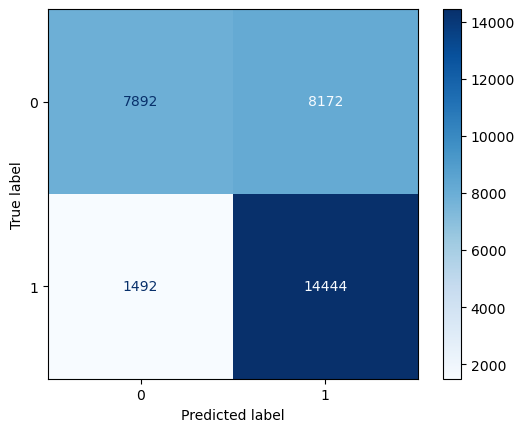

In [ ]:
### Here we will evaluate how does Naive Bayes, specially The Gaussian Naive Bayes for the binary data that we have

## Pipeline Creation 
pipeline_steps = [('scalar', StandardScaler()), ('naive_model',GaussianNB())]
naive_model = Pipeline(pipeline_steps)

## Lets do the hyperparameter tuning in order to find the best model, Gaussian NB doesnot have many hyperparamters becuase it learns from the data it self, so for that reason we will only be tuning on var_smoothing which adds a small value to the variance in case the variance is too low to cause divide by zero problem 

params = {'naive_model__var_smoothing':[1e-8,1e-9,1e-10]}
## Cross_validation 
naive_tuned = GridSearchCV(naive_model, param_grid=params, cv = 5, n_jobs = -1)
naive_tuned.fit(X_train, y_train)
best_naive_model = naive_tuned.best_estimator_


## Parameters to evaluate the model 
training_pred = best_naive_model.predict(X_train)
testing_pred = best_naive_model.predict(X_test)
testing_proba = best_naive_model.predict_proba(X_test)[:,1]
training_proba = best_naive_model.predict_proba(X_train)[:,1]

## Here we will be calculating the metrics such as precisoin, recall, log-loss, fpr and f1-score

testing_accuracy = accuracy_score(y_test, testing_pred)
training_accuracy = accuracy_score(y_train, training_pred)
print(f"The training accuracy and testing accuracy of the model is {training_accuracy*100.:2f}% and {testing_accuracy*100.:2f}% repsectively")

print("Evalutaion Done ----------")
precison = precision_score(y_test, testing_pred)
print(f"The precision of the whole model is {precison*100.:2f}")
recall = recall_score(y_test, testing_pred)
print(f"The recall of the whole model is {recall*100.:2f}")
f1_scores = f1_score(y_test, testing_pred)
print(f"The f1_score of the whole model is {f1_scores*100.:2f}")
fpr,tpr, threshold = roc_curve(y_test, testing_proba)
roc_value = roc_auc_score(y_test, testing_proba)
print(f"The roc_score of the whole model is {roc_value}")
testing_log_loss = log_loss(y_test, testing_proba)
print(f"The testing loss of the model is {testing_log_loss:.4f}")
training_log_loss = log_loss(y_train, training_proba)
print(f"The training loss of the model is {training_log_loss:.4f}")


print("Visulatization plotted ---------> ")
evaluation_matrix = confusion_matrix(y_test, testing_pred)
display = ConfusionMatrixDisplay(confusion_matrix=evaluation_matrix)
display.plot(cmap='Blues')
plt.show()


### The log loss of the model is > 1.0 which means that the model is not performing good or is overperforming. This is becuase the model has been fed with the data which is both binomial and continous. GaussianNB is good for the continous data. But due to the data structure the model fails to do good with all the features. For that reason the model perfomed bad in terms of log-loss